<a href="https://colab.research.google.com/github/AntonyMorenoCod/regresion-logistica-cancer/blob/main/InformeRegresi%C3%B3nLog%C3%ADsticaAMorenos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ──  Importar librerías y cargar el dataset ──────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# Cargar dataset de cáncer de mama (binario: maligno=1 / benigno=0)
datos = load_breast_cancer()
df = pd.DataFrame(datos.data, columns=datos.feature_names)
df['diagnostico'] = datos.target

# Ver las primeras filas
print("Filas y columnas:", df.shape)
df.head()


Filas y columnas: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


=== Valores nulos ===
0 valores nulos en total

=== Distribución del diagnóstico ===
diagnostico
1    357
0    212
Name: count, dtype: int64
1 = Maligno | 0 = Benigno


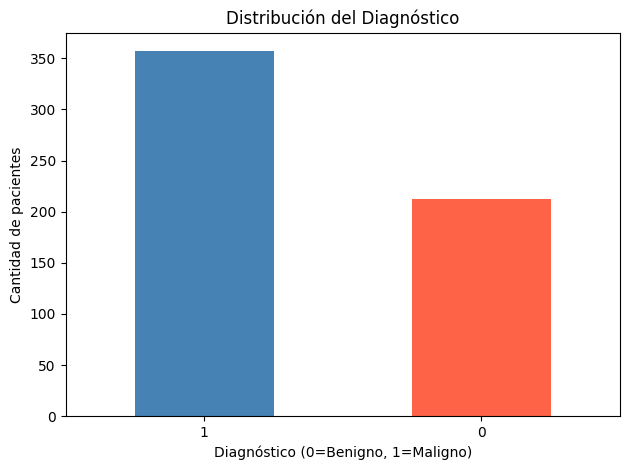

In [4]:
# Valores nulos
print("=== Valores nulos ===")
print(df.isnull().sum().sum(), "valores nulos en total")

# Distribución de la variable objetivo
print("\n=== Distribución del diagnóstico ===")
print(df['diagnostico'].value_counts())
print("1 = Maligno | 0 = Benigno")

# Gráfico de distribución
df['diagnostico'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Distribución del Diagnóstico')
plt.xlabel('Diagnóstico (0=Benigno, 1=Maligno)')
plt.ylabel('Cantidad de pacientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
# ── Preparación de datos ─────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Seleccionar solo las columnas "mean" como predictoras
columnas_mean = [col for col in df.columns if 'mean' in col]
X = df[columnas_mean]
y = df['diagnostico']

print("Variables predictoras:", X.shape[1])
print("Columnas usadas:", list(X.columns))

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nDatos de entrenamiento:", X_train.shape)
print("Datos de prueba:       ", X_test.shape)

Variables predictoras: 10
Columnas usadas: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension']

Datos de entrenamiento: (455, 10)
Datos de prueba:        (114, 10)


=== Métricas del modelo ===
Accuracy  (Exactitud):  0.9386
Precision (Precisión):  0.9444
Recall    (Sensibilidad):0.9577
F1-Score:               0.9510


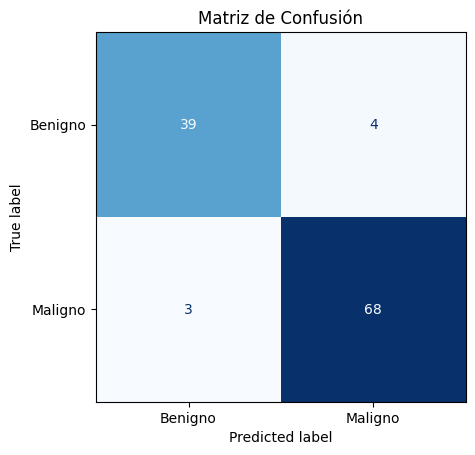

In [6]:
# ──  Entrenamiento del modelo ─────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)

# Crear y entrenar el modelo
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train, y_train)

# Predecir sobre datos de prueba
y_pred = modelo.predict(X_test)

# Métricas
print("=== Métricas del modelo ===")
print(f"Accuracy  (Exactitud):  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (Precisión):  {precision_score(y_test, y_pred):.4f}")
print(f"Recall    (Sensibilidad):{recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:               {f1_score(y_test, y_pred):.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benigno","Maligno"])
disp.plot(colorbar=False, cmap='Blues')
plt.title("Matriz de Confusión")
plt.show()

=== Probabilidades de prediccion (primeros 10 casos) ===
 Prob. Benigno (0)  Prob. Maligno (1)  Prediccion  Real
            0.0834             0.9166           1     1
            0.9944             0.0056           0     0
            0.9772             0.0228           0     0
            0.0271             0.9729           1     1
            0.0039             0.9961           1     1
            1.0000             0.0000           0     0
            1.0000             0.0000           0     0
            0.9083             0.0917           0     0
            0.2781             0.7219           1     1
            0.0050             0.9950           1     1


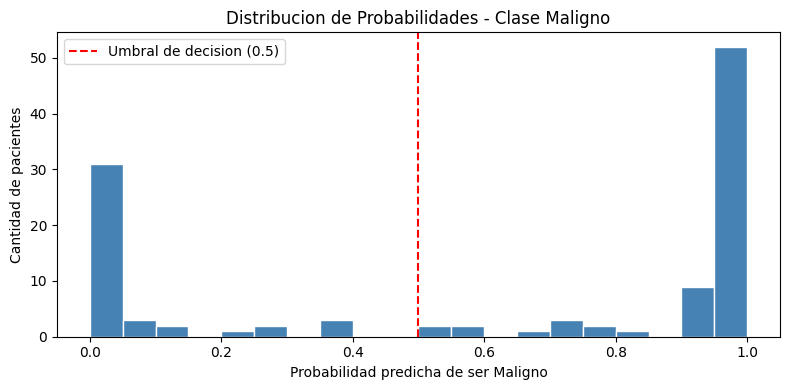

In [7]:
# ──  predict_proba() ──────────────────────────────────────────
# Obtener probabilidades de pertenencia a cada clase
probabilidades = modelo.predict_proba(X_test)

# Mostrar las primeras 10 predicciones con sus probabilidades
import pandas as pd
resultados = pd.DataFrame({
    'Prob. Benigno (0)': probabilidades[:, 0].round(4),
    'Prob. Maligno (1)': probabilidades[:, 1].round(4),
    'Prediccion':        y_pred,
    'Real':              y_test.values
}).head(10)

print("=== Probabilidades de prediccion (primeros 10 casos) ===")
print(resultados.to_string(index=False))

# Gráfico de distribución de probabilidades para clase Maligno
plt.figure(figsize=(8, 4))
plt.hist(probabilidades[:, 1], bins=20, color='steelblue', edgecolor='white')
plt.axvline(0.5, color='red', linestyle='--', label='Umbral de decision (0.5)')
plt.title('Distribucion de Probabilidades - Clase Maligno')
plt.xlabel('Probabilidad predicha de ser Maligno')
plt.ylabel('Cantidad de pacientes')
plt.legend()
plt.tight_layout()
plt.show()

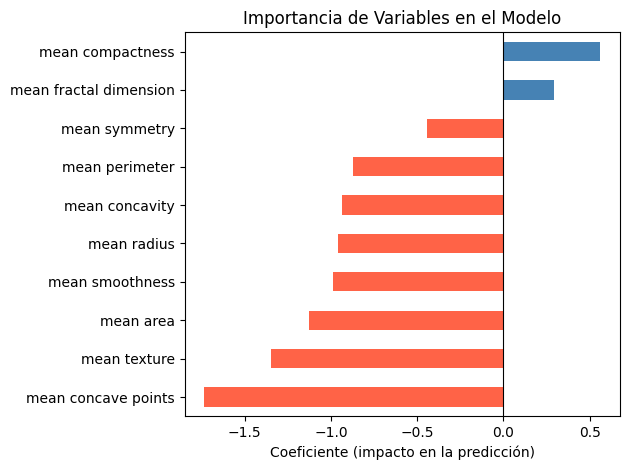

In [8]:
# ── Importancia de variables (coeficientes) ──────────────────
columnas_mean = [col for col in df.columns if 'mean' in col]

coef = pd.Series(modelo.coef_[0], index=columnas_mean).sort_values()

coef.plot(kind='barh', color=['tomato' if c < 0 else 'steelblue' for c in coef])
plt.title('Importancia de Variables en el Modelo')
plt.xlabel('Coeficiente (impacto en la predicción)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()